In [122]:
import tensorflow as tf
import tensorflow_probability as tfp

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

tfd = tfp.distributions

# ==========================================
# 1. THE NEURAL NETWORK
# ==========================================
class TFBasicStudentTNet(tf.keras.Model):
    def __init__(self, input_dim=9):
        super(TFBasicStudentTNet, self).__init__()
        
        # The Hidden Layer (Rule of 10 sizing)
        self.hidden_layer = tf.keras.Sequential([
            tf.keras.layers.Dense(1, activation='relu', input_shape=(input_dim,)),
            tf.keras.layers.Dropout(0.3)
        ])
        
        # The Three Output Heads
        self.mu_head = tf.keras.layers.Dense(1)
        
        # # Softplus ensures strict positivity for scale and degrees of freedom
        # self.sigma_head = tf.keras.layers.Dense(1, activation='softplus')
        # self.nu_head = tf.keras.layers.Dense(1, activation='softplus')

    def call(self, inputs, training=False):
        # Forward pass! 'training' flag handles Dropout automatically
        h = self.hidden_layer(inputs, training=training)
        
        mu = self.mu_head(h)
        # sigma = self.sigma_head(h) + 1e-6  # Prevent exact zero
        # nu = self.nu_head(h) + 2.1         # Ensure df > 2 for finite variance
        return mu
        
        # return mu, sigma, nu

# ==========================================
# 2. YOUR CUSTOM PIT MOMENT LOSS
# ==========================================

def generalized_pit_moment_loss(mu_pred, sigma_pred, nu_pred, y_target, weights, nll_lambda=1.0):
    """
    Calculates the weighted squared difference between empirical PIT moments
    and theoretical U(0,1) moments.
    
    weights: A list or tensor of weights for each moment. 
             The length of this list defines the hyperparameter (how many moments).
             Example: [1.0, 0.5, 0.25, 0.1] evaluates 4 moments.
    """
    # 1. Create Distribution and Calculate PIT
    dist = tfd.StudentT(df=nu_pred, loc=mu_pred, scale=sigma_pred)
    pit_values = dist.cdf(y_target)
    
    num_moments = len(weights)
    moment_loss = 0.0
    
    # 2. Loop through the requested number of moments
    for k in range(1, num_moments + 1):
        # Convert k to float for TensorFlow math compatibility
        k_float = tf.cast(k, tf.float32)
        
        # Empirical k-th Raw Moment: Mean of (PIT^k)
        empirical_moment = tf.reduce_mean(tf.pow(pit_values, k_float))
        
        # Theoretical k-th Raw Moment of U(0,1)
        theoretical_moment = 1.0 / (k_float + 1.0)
        
        # Quadratic Difference
        # diff_sq = (empirical_moment - theoretical_moment)**2
        
        # # Squared Difference
        diff_sq = tf.square(empirical_moment - theoretical_moment)
        
        # Weight and accumulate
        moment_loss += weights[k - 1] * diff_sq

    # 3. Add Negative Log-Likelihood to maintain Sharpness!
    nll_loss = -tf.reduce_mean(dist.log_prob(y_target))
    
    # You can control the balance between Sharpness (NLL) and Calibration (Moments)
    total_loss = (nll_lambda * nll_loss) + moment_loss
    
    return total_loss


In [123]:
# # Hyperparameters: Evaluate 4 moments, heavily penalizing the 1st and 2nd.
# MOMENT_WEIGHTS = tf.constant([10.0, 5.0, 1.0, 0.5], dtype=tf.float32)

# @tf.function
# def train_step(X_batch, y_batch):
#     with tf.GradientTape() as tape:
#         mu, sigma, nu = model(X_batch, training=True)
        
#         # Call your generalized loss!
#         loss = generalized_pit_moment_loss(
#             mu, sigma, nu, y_batch, 
#             weights=MOMENT_WEIGHTS, 
#             nll_lambda=1.0  # Keep NLL active
#         )
        
#     gradients = tape.gradient(loss, model.trainable_variables)
#     optimizer.apply_gradients(zip(gradients, model.trainable_variables))
#     return loss

In [124]:
# import numpy as np
# import tensorflow as tf

# # Number of days in our synthetic dataset
# N_DAYS = 2000

# # 1. Generate dynamic underlying parameters
# # Let's say mu fluctuates between -5% and +5%
# true_mu = np.random.uniform(low=-0.05, high=0.05, size=(N_DAYS, 1))

# # Let's say sigma (volatility) fluctuates between 1% and 8%
# true_sigma = np.random.uniform(low=0.01, high=0.08, size=(N_DAYS, 1))

# # 2. Build X_train (The Features)
# # We stack them side-by-side. Shape will be (2000, 2)
# X_train_np = np.hstack([true_mu, true_sigma])

# # 3. Build y_train (The Targets)
# # We sample EXACTLY from the Normal distribution defined by each row's mu and sigma!
# y_train_np = np.random.normal(loc=true_mu, scale=true_sigma)

# # 4. Cast to TensorFlow Tensors
# # (Crucial: Deep Learning requires float32. NumPy defaults to float64, which will crash TF)
# X_train = tf.convert_to_tensor(X_train_np, dtype=tf.float32)
# y_train = tf.convert_to_tensor(y_train_np, dtype=tf.float32)

# print(f"X_train shape: {X_train.shape} | Contains [mu, sigma]")
# print(f"y_train shape: {y_train.shape} | Contains sampled returns")

In [125]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

N_DAYS = 3000

# 1. The True Constants
TRUE_SIGMA = 0.02
TRUE_NU = 30.0 # Fat tails!

# TRUE_NU = 5.0 # Fat tails!

# 2. The Slow Moving Mu (Drifts from -0.02 to +0.02 over 2000 days)
time_index = np.arange(N_DAYS)
true_mu = -0.02 + (0.04 * (time_index / N_DAYS))

# 3. Generate the Target Variable (y_t)
# To generate a custom Student-t in numpy, we draw from standard T, scale, and shift.
np.random.seed(42)
standard_t_noise = np.random.standard_t(df=TRUE_NU, size=N_DAYS)
y_actual = true_mu + (TRUE_SIGMA * standard_t_noise)

# 4. Create the Features (X_t)
# Feature 1: Normalized Time (0.0 to 1.0)
feat_time = time_index / N_DAYS

# Feature 2: 20-Day Rolling Mean (to simulate a technical indicator)
import pandas as pd
feat_ma20 = pd.Series(y_actual).rolling(window=20).mean().bfill().values

# Stack them to form the X tensor
# X_data_np = np.column_stack([feat_time, feat_ma20])
# X_data_np = np.column_stack([feat_time, true_mu])
X_data_np = np.column_stack([true_mu, feat_time])

y_data_np = y_actual.reshape(-1, 1)

# Split into Train and Test
split = 2000
X_train = tf.cast(X_data_np[:split], tf.float32)
y_train = tf.cast(y_data_np[:split], tf.float32)

X_test = tf.cast(X_data_np[split:], tf.float32)
y_test = tf.cast(y_data_np[split:], tf.float32)

true_mu_test = true_mu[split:]

In [126]:

# ==========================================
# 1. GENERATE TRAIN AND TEST DATA
# ==========================================
np.random.seed(42)
tf.random.set_seed(42)

# def generate_synthetic_data(n_days):
#     # true_mu = np.random.uniform(low=-0.05, high=0.05, size=(n_days, 1))
#     # true_sigma = np.random.uniform(low=0.01, high=0.08, size=(n_days, 1))
#     true_mu = np.random.uniform(low=0, high=0, size=(n_days, 1))
#     true_sigma = np.random.uniform(low=0.05, high=0.05, size=(n_days, 1))

#     X_np = np.hstack([true_mu, true_sigma])
#     y_np = np.random.normal(loc=true_mu, scale=true_sigma) # True data is Normal!
#     return tf.cast(X_np, tf.float32), tf.cast(y_np, tf.float32)

# X_train, y_train = generate_synthetic_data(2000)
# X_test, y_test = generate_synthetic_data(500)

# ==========================================
# 2. TRAINING SETUP WITH TEST EVALUATION
# ==========================================
model = TFBasicStudentTNet(input_dim=2)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.005)
MOMENT_WEIGHTS = tf.constant([1.0, 1.0, 1.0, 1], dtype=tf.float32)

nll_lambda = 1
@tf.function
def train_step(X_batch, y_batch):
    with tf.GradientTape() as tape:
        mu_pred = model(X_batch, training=True)
        # mu_pred, sigma_pred, nu_pred = model(X_batch, training=True)
        
# # 1. The True Constants
# TRUE_SIGMA = 0.02
# TRUE_NU = 30.0 # Fat tails!
        loss = generalized_pit_moment_loss(mu_pred, TRUE_SIGMA, TRUE_NU, y_batch, MOMENT_WEIGHTS, nll_lambda=nll_lambda)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss

@tf.function
def test_step(X_batch, y_batch):
    # training=False shuts off Dropout for evaluation
    # mu_pred, sigma_pred, nu_pred = model(X_batch, training=False)
    mu_pred = model(X_batch, training=False)

    loss = generalized_pit_moment_loss(mu_pred, TRUE_SIGMA, TRUE_NU, y_batch, MOMENT_WEIGHTS, nll_lambda=nll_lambda)
    return loss

epochs = 500
train_losses = []
test_losses = []

print("Training Model and Tracking Convergence...")
for epoch in range(epochs):
    train_loss = train_step(X_train, y_train)
    test_loss = test_step(X_test, y_test)
    
    train_losses.append(train_loss.numpy())
    test_losses.append(test_loss.numpy())
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {train_loss.numpy():.4f} | Test Loss: {test_loss.numpy():.4f}")

c:\Users\fe_ma\miniconda3\envs\quant-ai-lab-2\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Model and Tracking Convergence...
Epoch 000 | Train Loss: -2.3032 | Test Loss: -1.8469
Epoch 050 | Train Loss: -2.4363 | Test Loss: -1.9270
Epoch 100 | Train Loss: -2.4382 | Test Loss: -1.9330
Epoch 150 | Train Loss: -2.4335 | Test Loss: -1.8955
Epoch 200 | Train Loss: -2.4317 | Test Loss: -1.8662
Epoch 250 | Train Loss: -2.4327 | Test Loss: -1.9046
Epoch 300 | Train Loss: -2.4386 | Test Loss: -1.9028
Epoch 350 | Train Loss: -2.4346 | Test Loss: -1.9216
Epoch 400 | Train Loss: -2.4343 | Test Loss: -1.9380
Epoch 450 | Train Loss: -2.4394 | Test Loss: -1.8895


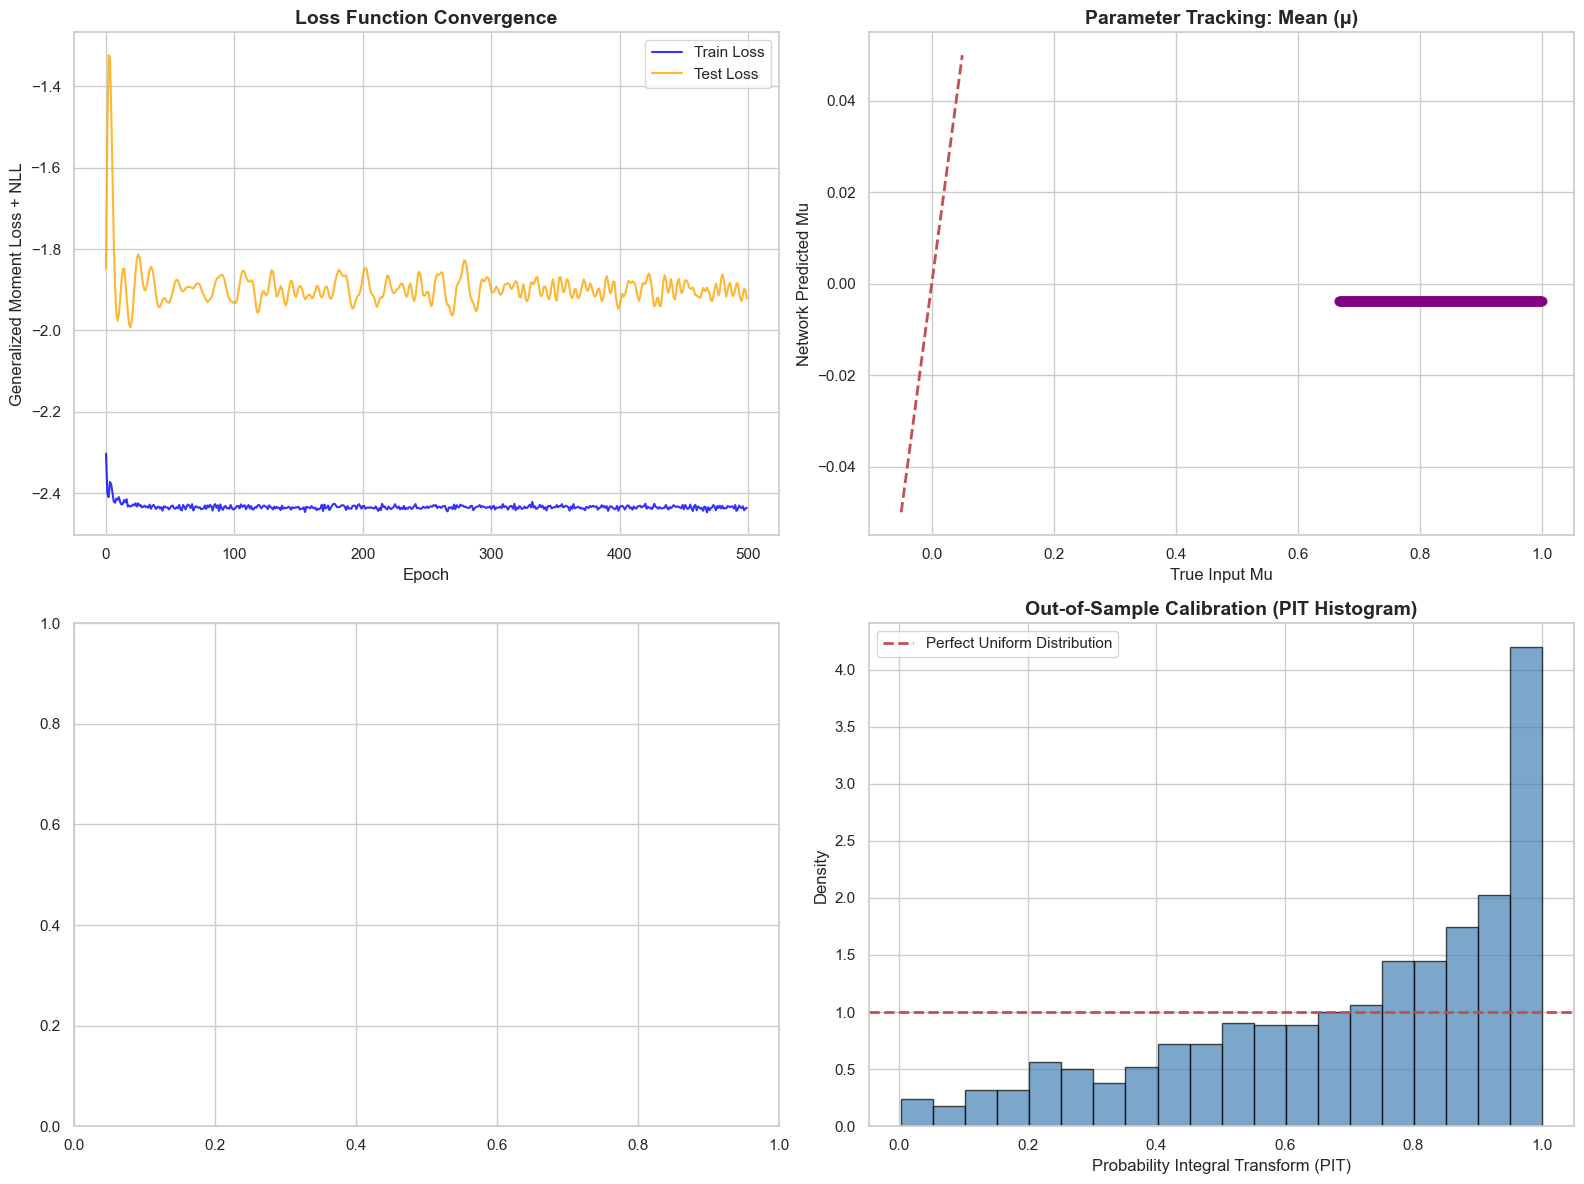


--- Diagnostic Insights ---
Average Predicted Degrees of Freedom (nu): 2.86


In [ ]:
# ==========================================
# 3. GENERATE TEST PREDICTIONS
# ==========================================
# pred_mu, pred_sigma, pred_nu = model(X_test, training=False)
pred_mu = model(X_test, training=False)

# Convert to NumPy for easy plotting
true_mu_test = X_test[:, 1].numpy()

pred_mu_np = pred_mu.numpy().flatten()
y_test_np = y_test.numpy().flatten()

# Calculate the Out-of-Sample PIT values using TensorFlow Probability
test_dist = tfd.StudentT(df=TRUE_NU, loc=pred_mu, scale=TRUE_SIGMA)
pit_values_test = test_dist.cdf(y_test).numpy().flatten()

# ==========================================
# 4. PLOTTING THE DIAGNOSTIC DASHBOARD
# ==========================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Plot 1: Loss Convergence ---
axes[0, 0].plot(train_losses, label="Train Loss", color="blue", alpha=0.8)
axes[0, 0].plot(test_losses, label="Test Loss", color="orange", alpha=0.8)
axes[0, 0].set_title("Loss Function Convergence", fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Generalized Moment Loss + NLL")
axes[0, 0].legend()

# --- Plot 2: Parameter Accuracy (Mu) ---
# A perfect model will align all points on the red dashed 45-degree line
axes[0, 1].scatter(true_mu_test, pred_mu_np, alpha=0.5, color="purple")
axes[0, 1].plot([-0.05, 0.05], [-0.05, 0.05], 'r--', lw=2) 
axes[1].set_title("Parameter Tracking: Mean (μ)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("True Input Mu")
axes[0, 1].set_ylabel("Network Predicted Mu")

# # --- Plot 3: Parameter Accuracy (Sigma) ---
# axes[1, 0].scatter(true_sigma_test, pred_sigma_np, alpha=0.5, color="teal")
# axes[1, 0].plot([0.01, 0.08], [0.01, 0.08], 'r--', lw=2)
# axes[1, 0].set_title("Parameter Tracking: Volatility (σ)", fontsize=14, fontweight='bold')
# axes[1, 0].set_xlabel("True Input Sigma")
# axes[1, 0].set_ylabel("Network Predicted Sigma")

# # --- Plot 3: Parameter Accuracy (Nu) ---
# axes[1, 1].scatter(true_sigma_test, pred_nu_np, alpha=0.5, color="teal")
# axes[1, 1].plot([0.01, 0.08], [0.01, 0.08], 'r--', lw=2)
# axes[1, 1].set_title("Parameter Tracking: Volatility (σ)", fontsize=14, fontweight='bold')
# axes[1, 1].set_xlabel("True Input Sigma")
# axes[1, 1].set_ylabel("Network Predicted Sigma")

# --- Plot 4: Out-of-Sample PIT Histogram ---
axes[1, 1].hist(pit_values_test, bins=20, density=True, color="steelblue", edgecolor='black', alpha=0.7)
axes[1, 1].axhline(y=1.0, color='r', linestyle='--', lw=2, label="Perfect Uniform Distribution")
axes[1, 1].set_title("Out-of-Sample Calibration (PIT Histogram)", fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel("Probability Integral Transform (PIT)")
axes[1, 1].set_ylabel("Density")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# ==========================================
# 5. THE "DEGREES OF FREEDOM" INSIGHT
# ==========================================
print("\n--- Diagnostic Insights ---")
print(f"Average Predicted Degrees of Freedom (nu): {np.mean(pred_nu_np):.2f}")

In [128]:
# # ==========================================
# # 3. GENERATE TEST PREDICTIONS
# # ==========================================
# # pred_mu, pred_sigma, pred_nu = model(X_test, training=False)
# pred_mu = model(X_test, training=False)


# # Convert to NumPy for easy plotting
# true_mu_test = X_test[:, 0].numpy()
# true_sigma_test = X_test[:, 1].numpy()

# pred_mu_np = pred_mu.numpy().flatten()
# pred_sigma_np = pred_sigma.numpy().flatten()
# pred_nu_np = pred_nu.numpy().flatten()
# y_test_np = y_test.numpy().flatten()

# # Calculate the Out-of-Sample PIT values using TensorFlow Probability
# test_dist = tfd.StudentT(df=pred_nu, loc=pred_mu, scale=pred_sigma)
# pit_values_test = test_dist.cdf(y_test).numpy().flatten()

# # ==========================================
# # 4. PLOTTING THE DIAGNOSTIC DASHBOARD
# # ==========================================
# sns.set_theme(style="whitegrid")
# fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# # --- Plot 1: Loss Convergence ---
# axes[0, 0].plot(train_losses, label="Train Loss", color="blue", alpha=0.8)
# axes[0, 0].plot(test_losses, label="Test Loss", color="orange", alpha=0.8)
# axes[0, 0].set_title("Loss Function Convergence", fontsize=14, fontweight='bold')
# axes[0, 0].set_xlabel("Epoch")
# axes[0, 0].set_ylabel("Generalized Moment Loss + NLL")
# axes[0, 0].legend()

# # --- Plot 2: Parameter Accuracy (Mu) ---
# # A perfect model will align all points on the red dashed 45-degree line
# axes[0, 1].scatter(true_mu_test, pred_mu_np, alpha=0.5, color="purple")
# axes[0, 1].plot([-0.05, 0.05], [-0.05, 0.05], 'r--', lw=2) 
# axes[0, 1].set_title("Parameter Tracking: Mean (μ)", fontsize=14, fontweight='bold')
# axes[0, 1].set_xlabel("True Input Mu")
# axes[0, 1].set_ylabel("Network Predicted Mu")

# # --- Plot 3: Parameter Accuracy (Sigma) ---
# axes[1, 0].scatter(true_sigma_test, pred_sigma_np, alpha=0.5, color="teal")
# axes[1, 0].plot([0.01, 0.08], [0.01, 0.08], 'r--', lw=2)
# axes[1, 0].set_title("Parameter Tracking: Volatility (σ)", fontsize=14, fontweight='bold')
# axes[1, 0].set_xlabel("True Input Sigma")
# axes[1, 0].set_ylabel("Network Predicted Sigma")

# # # --- Plot 3: Parameter Accuracy (Nu) ---
# # axes[1, 1].scatter(true_sigma_test, pred_nu_np, alpha=0.5, color="teal")
# # axes[1, 1].plot([0.01, 0.08], [0.01, 0.08], 'r--', lw=2)
# # axes[1, 1].set_title("Parameter Tracking: Volatility (σ)", fontsize=14, fontweight='bold')
# # axes[1, 1].set_xlabel("True Input Sigma")
# # axes[1, 1].set_ylabel("Network Predicted Sigma")

# # --- Plot 4: Out-of-Sample PIT Histogram ---
# axes[1, 1].hist(pit_values_test, bins=20, density=True, color="steelblue", edgecolor='black', alpha=0.7)
# axes[1, 1].axhline(y=1.0, color='r', linestyle='--', lw=2, label="Perfect Uniform Distribution")
# axes[1, 1].set_title("Out-of-Sample Calibration (PIT Histogram)", fontsize=14, fontweight='bold')
# axes[1, 1].set_xlabel("Probability Integral Transform (PIT)")
# axes[1, 1].set_ylabel("Density")
# axes[1, 1].legend()

# plt.tight_layout()
# plt.show()

# # ==========================================
# # 5. THE "DEGREES OF FREEDOM" INSIGHT
# # ==========================================
# print("\n--- Diagnostic Insights ---")
# print(f"Average Predicted Degrees of Freedom (nu): {np.mean(pred_nu_np):.2f}")

In [129]:
# # Initialize Model and Optimizer
# model = TFBasicStudentTNet(input_dim=X_train.shape[1])
# optimizer = tf.keras.optimizers.Adam(learning_rate=0.005)

# # ==========================================
# # HOW TO RUN IT
# # ==========================================
# # Assuming X_train and y_train are numpy arrays or tf.Tensors
# epochs = 150

# print("Training TensorFlow Model...")
# for epoch in range(epochs):
#     # Just pass your data into the compiled step
#     current_loss = train_step(X_train, y_train)
    
#     if epoch % 25 == 0:
#         print(f"Epoch {epoch:03d} | Loss: {current_loss.numpy():.4f}")

# simple model

Training Linear Network with PIT Moment Loss...
Epoch 000 | Total Loss: 2.6140
Epoch 100 | Total Loss: 0.0527
Epoch 200 | Total Loss: 0.0502
Epoch 300 | Total Loss: 0.0457
Epoch 400 | Total Loss: 0.0365
Epoch 500 | Total Loss: 0.0074
Epoch 600 | Total Loss: 0.0001
Epoch 700 | Total Loss: 0.0000
Epoch 800 | Total Loss: 0.0000
Epoch 900 | Total Loss: 0.0000

--- Final Learned Parameters ---
Target Mu Equation: mu_t = 0.040 * t - 0.020
Learned Mu Equation: mu_t = 0.030 * t + -0.016


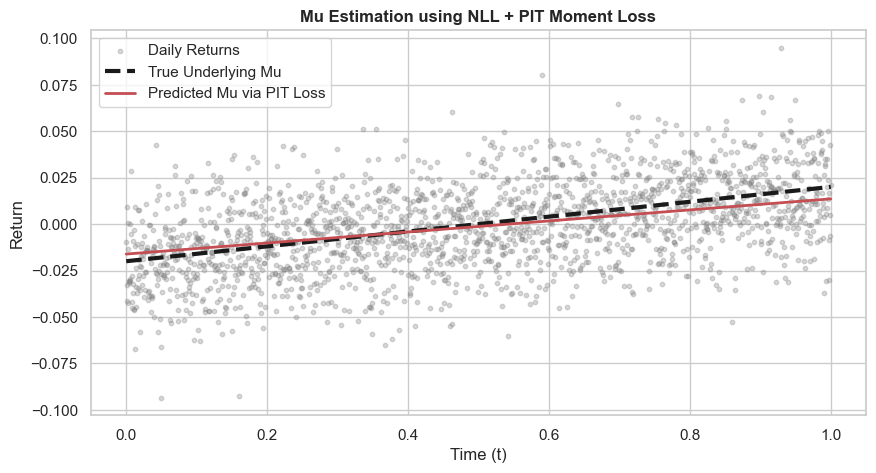

In [130]:
import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp
# import matplotlib.subplots as plt
import matplotlib.pyplot as plt

tfd = tfp.distributions

# ==========================================
# 1. GENERATE TRENDING STUDENT-T DATA
# ==========================================
np.random.seed(42)
tf.random.set_seed(42)

N_DAYS = 2000
TRUE_SIGMA = 0.02
TRUE_NU = 30.0

# Normalized Time (0 to 1)
feat_time = np.linspace(0, 1, N_DAYS).astype(np.float32).reshape(-1, 1)

# True Mu drifts from -0.02 to +0.02
true_mu = 0.04 * feat_time - 0.02 

# Generate Student-t noise
standard_t_noise = np.random.standard_t(df=TRUE_NU, size=(N_DAYS, 1)).astype(np.float32)
y_actual = true_mu + (TRUE_SIGMA * standard_t_noise)

X_train = tf.convert_to_tensor(feat_time)
y_train = tf.convert_to_tensor(y_actual)

# ==========================================
# 2. YOUR EXACT CUSTOM LOSS FUNCTION
# ==========================================
def generalized_pit_moment_loss(mu_pred, sigma_pred, nu_pred, y_target, weights, nll_lambda=1.0):
    dist = tfd.StudentT(df=nu_pred, loc=mu_pred, scale=sigma_pred)
    pit_values = dist.cdf(y_target)
    
    num_moments = len(weights)
    moment_loss = 0.0
    
    for k in range(1, num_moments + 1):
        k_float = tf.cast(k, tf.float32)
        empirical_moment = tf.reduce_mean(tf.pow(pit_values, k_float))
        theoretical_moment = 1.0 / (k_float + 1.0)
        diff_sq = tf.square(empirical_moment - theoretical_moment)
        moment_loss += weights[k - 1] * diff_sq

    nll_loss = -tf.reduce_mean(dist.log_prob(y_target))
    return (nll_lambda * nll_loss) + moment_loss

# ==========================================
# 3. THE LINEAR MAPPING NETWORK (No Hidden Layers)
# ==========================================
class LinearStudentTNet(tf.keras.Model):
    def __init__(self):
        super(LinearStudentTNet, self).__init__()
        # Direct linear mapping for Mu: Output = Weight * t + Bias
        self.mu_head = tf.keras.layers.Dense(1)
        
        # # Direct mappings for Sigma and Nu
        # self.sigma_head = tf.keras.layers.Dense(1, activation='softplus')
        # self.nu_head = tf.keras.layers.Dense(1, activation='softplus')

    def call(self, inputs):
        mu = self.mu_head(inputs)
        # sigma = self.sigma_head(inputs) + 1e-6
        # nu = self.nu_head(inputs) + 2.1
        return mu
        # return mu, sigma, nu

# ==========================================
# 4. TRAINING LOOP
# ==========================================
model = LinearStudentTNet()
# We use a smaller learning rate because probabilistic gradients are sensitive
optimizer = tf.keras.optimizers.Adam(learning_rate=0.01) 
# MOMENT_WEIGHTS = tf.constant([10.0, 5.0, 1.0, 0.5], dtype=tf.float32)
MOMENT_WEIGHTS = tf.constant([1.0, 1.0, 1.0, 1.0, 1.0, 1.0], dtype=tf.float32)

@tf.function
def train_step(X_batch, y_batch):
    with tf.GradientTape() as tape:
        mu = model(X_batch)
        # mu, sigma, nu = model(X_batch)
        loss = generalized_pit_moment_loss(mu, TRUE_SIGMA, TRUE_NU, y_batch, MOMENT_WEIGHTS, nll_lambda=0.0)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss

epochs = 1000
print("Training Linear Network with PIT Moment Loss...")
for epoch in range(epochs):
    loss_val = train_step(X_train, y_train)
    if epoch % 100 == 0:
        print(f"Epoch {epoch:03d} | Total Loss: {loss_val.numpy():.4f}")

# ==========================================
# 5. EVALUATION
# ==========================================
import matplotlib.pyplot as plt

# pred_mu, pred_sigma, pred_nu = model(X_train)
pred_mu = model(X_train)

print("\n--- Final Learned Parameters ---")
# Extract the exact a and b for the mu equation
a = model.mu_head.weights[0].numpy()[0][0]
b = model.mu_head.weights[1].numpy()[0]
print(f"Target Mu Equation: mu_t = 0.040 * t - 0.020")
print(f"Learned Mu Equation: mu_t = {a:.3f} * t + {b:.3f}")
# print(f"Average Predicted Sigma: {tf.reduce_mean(pred_sigma).numpy():.4f} (Target: {TRUE_SIGMA})")
# print(f"Average Predicted Nu:    {tf.reduce_mean(pred_nu).numpy():.4f} (Target: {TRUE_NU})")

# Plot the learned Mu trend against the actual noise
plt.figure(figsize=(10, 5))
plt.scatter(feat_time.flatten(), y_actual.flatten(), alpha=0.3, color='gray', s=10, label="Daily Returns")
plt.plot(feat_time.flatten(), true_mu.flatten(), 'k--', lw=3, label="True Underlying Mu")
plt.plot(feat_time.flatten(), pred_mu.numpy().flatten(), 'r-', lw=2, label="Predicted Mu via PIT Loss")
plt.title("Mu Estimation using NLL + PIT Moment Loss", fontweight='bold')
plt.xlabel("Time (t)")
plt.ylabel("Return")
plt.legend()
plt.show()

In [176]:
true_nu_train = 10 * t_train + 3.0
true_nu_train

array([[ 3.       ],
       [ 3.0050025],
       [ 3.010005 ],
       ...,
       [12.989995 ],
       [12.994997 ],
       [13.       ]], shape=(2000, 1), dtype=float32)

In [ ]:
import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp
import matplotlib.subplots as plt
import seaborn as sns

tfd = tfp.distributions

# ==========================================
# 1. GENERATE QUADRATIC (PARABOLIC) DATA
# ==========================================
np.random.seed(42)
tf.random.set_seed(42)

N_TRAIN = 2000
t_train = np.linspace(0, 1, N_TRAIN).astype(np.float32).reshape(-1, 1)

# True Mu is now a U-shaped Parabola! 
# It drops from 0.02 down to -0.02, then curves back up to 0.02
true_mu_train = 0.16 * (t_train - 0.5)**2 - 0.02

# Sigma expands quadratically
true_sigma_train = 0.02 + 0.05 * (t_train)**2

# Nu curves smoothly
true_nu_train = 15.0 * np.sin(t_train * 3.14) + 4.0

# Generate Targets
noise_train = np.array([np.random.standard_t(df=v) for v in true_nu_train.flatten()]).astype(np.float32).reshape(-1, 1)
y_train_np = true_mu_train + (true_sigma_train * noise_train)

X_train = tf.convert_to_tensor(t_train)
y_train = tf.convert_to_tensor(y_train_np)

# ==========================================
# 2. THE WIDE & DEEP NETWORK (SKIP CONNECTIONS)
# ==========================================
class WideAndDeepStudentTNet(tf.keras.Model):
    def __init__(self):
        super(WideAndDeepStudentTNet, self).__init__()
        
        # --- THE DEEP PATH (Non-Linear) ---
        # We use 'swish' (x * sigmoid(x)) because it draws perfectly smooth polynomials!
        self.hidden = tf.keras.layers.Dense(16, activation='swish')
        
        # --- THE WIDE PATH (Strictly Linear baselines we already proved) ---
        self.mu_linear = tf.keras.layers.Dense(1, kernel_initializer='zeros', bias_initializer='zeros')
        self.sigma_linear = tf.keras.layers.Dense(1, kernel_initializer='zeros', bias_initializer=tf.keras.initializers.Constant(0.02))
        self.nu_linear = tf.keras.layers.Dense(1, kernel_initializer='zeros', bias_initializer=tf.keras.initializers.Constant(2.9))
        
        # --- THE CURVE MODIFIERS (Outputs of the hidden layer) ---
        # These start at zero, meaning on Epoch 1, the network is PURELY LINEAR!
        self.mu_curve = tf.keras.layers.Dense(1, kernel_initializer='zeros', bias_initializer='zeros')
        self.sigma_curve = tf.keras.layers.Dense(1, kernel_initializer='zeros', bias_initializer='zeros')
        self.nu_curve = tf.keras.layers.Dense(1, kernel_initializer='zeros', bias_initializer='zeros')

    def call(self, inputs):
        # 1. Calculate the curves
        h = self.hidden(inputs)
        
        # 2. Add the Strict Linear Baseline to the Smooth Non-Linear Curves!
        raw_mu = self.mu_linear(inputs) + self.mu_curve(h)
        raw_sigma = self.sigma_linear(inputs) + self.sigma_curve(h)
        raw_nu = self.nu_linear(inputs) + self.nu_curve(h)
        
        # 3. Apply ReLU safety limits
        sigma = tf.nn.relu(raw_sigma) + 1e-6
        nu = tf.nn.relu(raw_nu) + 2.1
        
        return raw_mu, sigma, nu

# Loss Function
def nll_loss_fn(mu_pred, sigma_pred, nu_pred, y_target):
    dist = tfd.StudentT(df=nu_pred, loc=mu_pred, scale=sigma_pred)
    return -tf.reduce_mean(dist.log_prob(y_target))

# ==========================================
# 3. TRAINING LOOP
# ==========================================
model = WideAndDeepStudentTNet()
optimizer = tf.keras.optimizers.Adam(learning_rate=0.015) 

@tf.function
def train_step(X_batch, y_batch):
    with tf.GradientTape() as tape:
        mu, sigma, nu = model(X_batch)
        loss = nll_loss_fn(mu, sigma, nu, y_batch)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss

epochs = 800
print("Training Wide & Deep Network on Polynomial Data...")
for epoch in range(epochs):
    loss = train_step(X_train, y_train)
    if epoch % 100 == 0:
        print(f"Epoch {epoch:03d} | NLL Loss: {loss.numpy():.4f}")

# ==========================================
# 4. DASHBOARD
# ==========================================
import matplotlib.pyplot as plt

pred_mu_train, pred_sigma_train, pred_nu_train = model(X_train)

# Flatten for plotting
pred_mu = tf.reshape(pred_mu_train, [-1]).numpy()
pred_sigma = tf.reshape(pred_sigma_train, [-1]).numpy()
pred_nu = tf.reshape(pred_nu_train, [-1]).numpy()

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# Plot Mu
axes[0].plot(t_train.flatten(), true_mu_train.flatten(), 'k--', lw=3, label="True Quadratic Mu")
axes[0].plot(t_train.flatten(), pred_mu, 'r-', lw=2, label="Predicted Wide & Deep Mu")
axes[0].set_title(r"Tracking Non-Linear Center ($\mu_t$)", fontweight='bold')
axes[0].legend()

# Plot Sigma
axes[1].plot(t_train.flatten(), true_sigma_train.flatten(), 'k--', lw=3, label="True Quadratic Sigma")
axes[1].plot(t_train.flatten(), pred_sigma, 'g-', lw=2, label="Predicted Wide & Deep Sigma")
axes[1].set_title(r"Tracking Non-Linear Volatility ($\sigma_t$)", fontweight='bold')
axes[1].legend()

# Plot Nu
axes[2].plot(t_train.flatten(), true_nu_train.flatten(), 'k--', lw=3, label="True Sinusoidal Nu")
axes[2].plot(t_train.flatten(), pred_nu, 'm-', lw=2, label="Predicted Wide & Deep Nu")
axes[2].set_title(r"Tracking Non-Linear Tail Risk ($\nu_t$)", fontweight='bold')
axes[2].set_xlabel("Time (t)")
axes[2].legend()

plt.tight_layout()
plt.show()

# New Good Model

## Libraries

In [53]:
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_probability as tfp
tfd = tfp.distributions

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('..')  # Ensure the notebook can see the src/ folder
from src.evaluation.metrics import block_ks_test


## MODEL & LOSS FUNCTION

In [54]:
# ==========================================
# 2. THE WIDE & DEEP NETWORK (SKIP CONNECTIONS)
# ==========================================
class WideAndDeepStudentTNet(tf.keras.Model):
    def __init__(self):
        super(WideAndDeepStudentTNet, self).__init__()
        
        # --- THE DEEP PATH (Non-Linear) ---
        # We use 'swish' (x * sigmoid(x)) because it draws perfectly smooth polynomials!
        self.hidden = tf.keras.layers.Dense(16, activation='swish')
        
        # --- THE WIDE PATH (Strictly Linear baselines we already proved) ---
        self.mu_linear = tf.keras.layers.Dense(1, kernel_initializer='zeros', bias_initializer='zeros')
        self.sigma_linear = tf.keras.layers.Dense(1, kernel_initializer='zeros', bias_initializer=tf.keras.initializers.Constant(0.02))
        self.nu_linear = tf.keras.layers.Dense(1, activation='softplus', kernel_initializer='zeros', bias_initializer=tf.keras.initializers.Constant(10.9))
        
        # --- THE CURVE MODIFIERS (Outputs of the hidden layer) ---
        # These start at zero, meaning on Epoch 1, the network is PURELY LINEAR!
        self.mu_curve = tf.keras.layers.Dense(1, kernel_initializer='zeros', bias_initializer='zeros')
        self.sigma_curve = tf.keras.layers.Dense(1, kernel_initializer='zeros', bias_initializer='zeros')
        self.nu_curve = tf.keras.layers.Dense(1, activation='softplus', kernel_initializer='zeros', bias_initializer='zeros')

    def call(self, inputs):
        # 1. Calculate the curves
        h = self.hidden(inputs)
        
        # 2. Add the Strict Linear Baseline to the Smooth Non-Linear Curves!
        raw_mu = self.mu_linear(inputs) + self.mu_curve(h)
        raw_sigma = self.sigma_linear(inputs) + self.sigma_curve(h)
        # raw_mu = self.mu_linear(inputs)
        # raw_sigma = self.sigma_linear(inputs)
        raw_nu = self.nu_linear(inputs) + self.nu_curve(h)
        # raw_nu = self.nu_linear(inputs)

        # 3. Apply ReLU safety limits
        sigma = tf.nn.relu(raw_sigma) + 1e-6
        # nu = tf.nn.relu(raw_nu) + 2.1
        nu = raw_nu + 2.1
        
        return raw_mu, sigma, nu


# Loss Function
def nll_loss_fn(mu_pred, sigma_pred, nu_pred, y_target):
    dist = tfd.StudentT(df=nu_pred, loc=mu_pred, scale=sigma_pred)
    return -tf.reduce_mean(dist.log_prob(y_target))



In [55]:
# ==========================================
# 2. MODEL & LOSS FUNCTION
# ==========================================

class LinearStudentTNet(tf.keras.Model):
    def __init__(self):
        super(LinearStudentTNet, self).__init__()
        # self.mu_head = tf.keras.layers.Dense(1)
        # self.sigma_head = tf.keras.layers.Dense(1)
        # # self.nu_head = tf.keras.layers.Dense(1)
        # self.nu_head = tf.keras.layers.Dense(1, activation='softplus')
    # 1. Initialize Mu to start exactly at a flat 0.0
        self.mu_head = tf.keras.layers.Dense(
            1, 
            kernel_initializer='zeros', 
            bias_initializer='zeros'
        )
        
        # 2. Initialize Sigma to start at a flat 0.02
        self.sigma_head = tf.keras.layers.Dense(
            1, 
            kernel_initializer='zeros', 
            bias_initializer=tf.keras.initializers.Constant(0.02)
        )
        
        # 3. Initialize Nu to start at a flat 5.1 (2.9 bias + 2.1 shift)
        # This keeps the tails fat enough to avoid blowing up on early outliers
        self.nu_head = tf.keras.layers.Dense(
            1, 
            activation='softplus',
            kernel_initializer='zeros', 
            bias_initializer=tf.keras.initializers.Constant(7.9)
        )

    def call(self, inputs):
        mu = self.mu_head(inputs)
        raw_sigma = self.sigma_head(inputs)
        sigma = tf.nn.relu(raw_sigma) + 1e-6
        
        nu = self.nu_head(inputs) + 2.1

        # raw_nu = self.nu_head(inputs) + 2.1
        # nu = tf.nn.relu(raw_nu) + 2.1

        return mu, sigma, nu


## GENERATE TRAIN & TEST DATA (Extrapolating Time)

In [56]:
from datetime import date
from src.data.data_loader import fetch_asset_data
from src.features.features import rolling_t_fit, features_lags, create_features

start_date = date(2015, 12, 31)
# start_date = date(2022, 12, 31)
end_date = date(2025, 12, 31)
window_size = 22 * 6
porcentage_train = 0.8
# model_classes = {'BTC-USD': 'Basic', 'ARKK': 'Residual', 'USO': 'Basic'} USDCLP=X
ticker = 'USO'
ticker = 'USDCLP=X'

# ticker = 'BTC-USD'

df = fetch_asset_data(ticker=ticker, start=start_date, end=end_date, features=[])
if ticker == 'USDCLP=X':
    df.loc[df.prices < 200, 'prices'] = 680

df_vix = fetch_asset_data(ticker='^VIX', start=start_date, end=end_date, features=[])
df_vix = (df_vix[['prices']]) / np.sqrt(252)
df_vix.columns = ['VIX']
df_features = create_features(df, df_vix, window_size, n_lags=2)
df_features.dropna(inplace=True)
df_features = df_features.astype('float32')
df_y = df_features['returns']
df_X = df_features.drop(columns=['returns'])


Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')
Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


In [57]:
df_features.dropna(inplace=True)
df_features = df_features.astype('float32')
df_y = df_features['returns']
df_X = df_features.drop(columns=['returns'])

In [58]:
# ==========================================
# 3. TRAINING LOOP
# ==========================================
# model = WideAndDeepStudentTNet()
model = LinearStudentTNet()
optimizer = tf.keras.optimizers.Adam(learning_rate=0.015) 

@tf.function
def train_step(X_batch, y_batch):
    with tf.GradientTape() as tape:
        mu, sigma, nu = model(X_batch)
        loss = nll_loss_fn(mu, sigma, nu, y_batch)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss

In [ ]:
n_train = int(porcentage_train * len(df_X))
# df_y_test = df_y.iloc[n_train:]
# y_test = tf.convert_to_tensor(np.matrix(df_y_test))
# y_test_flat = tf.reshape(y_test, [-1])


test_window = 22
epochs = 500
count = 0
# epochs = 500

print("Training Wide & Deep Network on Polynomial Data...")

pit_values_test_total = []
dates_test_total = pd.Series([])

pred_sigma_test_total = np.array([])
pred_nu_test_total = np.array([])
pred_mu_test_total = np.array([])

while n_train < len(df_X):
    df_X_train = df_X.iloc[:n_train]
    df_y_train = df_y.iloc[:n_train]
    
    df_X_test = df_X.iloc[n_train:n_train + test_window]
    df_y_test = df_y.iloc[n_train:n_train + test_window]

    X_train = tf.convert_to_tensor(np.matrix(df_X_train))
    y_train = tf.convert_to_tensor(np.matrix(df_y_train))
    X_test = tf.convert_to_tensor(np.matrix(df_X_test))
    y_test = tf.convert_to_tensor(np.matrix(df_y_test))

    for epoch in range(epochs):
        loss = train_step(X_train, y_train)
        if epoch % 100 == 0:
            print(f"Epoch {epoch:03d} | NLL Loss: {loss.numpy():.4f}")

    

    # Test results
    pred_mu_test, pred_sigma_test, pred_nu_test = model(X_test)
    dates_test_total = pd.concat([dates_test_total, pd.Series(df_X_test.index)])  #= np.hstack((dates_test_total, df_X_test.index))
    # dates_test_total = np.hstack((dates_test_total, df_X_test.index))
    # 1. Force predictions to be flat 1D tensors of shape (326,)
    pred_mu_flat = tf.reshape(pred_mu_test, [-1])
    pred_sigma_flat = tf.reshape(pred_sigma_test, [-1])
    pred_nu_flat = tf.reshape(pred_nu_test, [-1])

    pred_mu_test_total = np.hstack((pred_mu_test_total, pred_mu_flat))
    pred_sigma_test_total = np.hstack((pred_sigma_test_total, pred_sigma_flat))
    pred_nu_test_total = np.hstack((pred_nu_test_total, pred_nu_flat))

    # dates_test_total.append(df_X_test.index)

    # dates_test_total.append(pred_mu_test) 
    # pred_sigma_test_total.append(pred_sigma_test)
    # pred_nu_test_total.append(pred_nu_test)


    # 2. Force the targets to be a flat 1D tensor of shape (326,)
    y_test_flat = tf.reshape(y_test, [-1])

    # 3. Create the distribution with the flattened parameters
    test_dist = tfd.StudentT(
        df=pred_nu_flat, 
        loc=pred_mu_flat, 
        scale=pred_sigma_flat
    )
    # pit_values_test_total.append(test_dist.cdf(y_test_flat).numpy())
    pit_values_test_total = np.hstack((pit_values_test_total, test_dist.cdf(y_test_flat).numpy()))
    n_train += test_window
    # if count >= 2:
    #     break
    # else:
    #     count += 1



Training Wide & Deep Network on Polynomial Data...
Epoch 000 | NLL Loss: 19.4386
Epoch 100 | NLL Loss: 1.6295
Epoch 200 | NLL Loss: 1.5390
Epoch 300 | NLL Loss: 1.5894
Epoch 400 | NLL Loss: 1.5154


C:\Users\fe_ma\AppData\Local\Temp\ipykernel_21188\721371150.py:38: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  dates_test_total = pd.concat([dates_test_total, pd.Series(df_X_test.index)])  #= np.hstack((dates_test_total, df_X_test.index))


Epoch 000 | NLL Loss: 1.5596
Epoch 100 | NLL Loss: 1.5302
Epoch 200 | NLL Loss: 1.5780
Epoch 300 | NLL Loss: 1.5402
Epoch 400 | NLL Loss: 1.5248
Epoch 000 | NLL Loss: 1.5131
Epoch 100 | NLL Loss: 1.5741
Epoch 200 | NLL Loss: 1.5347
Epoch 300 | NLL Loss: 1.5106
Epoch 400 | NLL Loss: 1.5083
Epoch 000 | NLL Loss: 1.4997
Epoch 100 | NLL Loss: 1.4923
Epoch 200 | NLL Loss: 1.4847
Epoch 300 | NLL Loss: 1.4903
Epoch 400 | NLL Loss: 1.4900
Epoch 000 | NLL Loss: 1.4788
Epoch 100 | NLL Loss: 1.4986
Epoch 200 | NLL Loss: 1.4854
Epoch 300 | NLL Loss: 1.4741
Epoch 400 | NLL Loss: 1.4835
Epoch 000 | NLL Loss: 1.4765
Epoch 100 | NLL Loss: 1.4769
Epoch 200 | NLL Loss: 1.4855
Epoch 300 | NLL Loss: 1.4764
Epoch 400 | NLL Loss: 1.4975
Epoch 000 | NLL Loss: 1.4806
Epoch 100 | NLL Loss: 1.4719
Epoch 200 | NLL Loss: 1.4785
Epoch 300 | NLL Loss: 1.4754
Epoch 400 | NLL Loss: 1.4768
Epoch 000 | NLL Loss: 1.4860
Epoch 100 | NLL Loss: 1.4677
Epoch 200 | NLL Loss: 1.5315
Epoch 300 | NLL Loss: 1.4809
Epoch 400 | NL

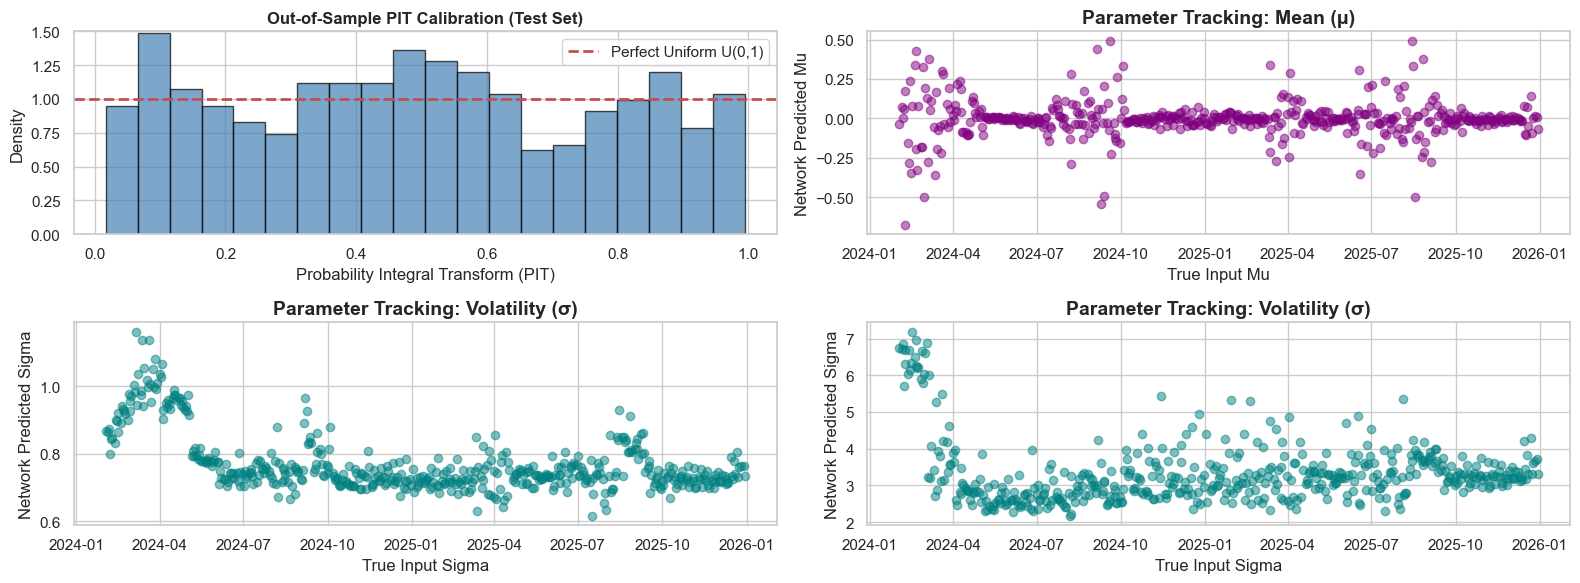


--- INDEPENDENT BLOCK TEST SUMMARY (495-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 0
True Failure Rate:        0.0%


,Start_Date,End_Date,KS_Stat,P_Value,Status
0,2024-02-02,2025-12-30,0.054775,0.098816,✅ PASSED


In [ ]:
# Set up the Dashboard
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 6))

# --- PANEL 2: Out-of-Sample PIT Histogram ---
axes[0, 0].hist(pit_values_test_total, bins=20, density=True, color="steelblue", edgecolor='black', alpha=0.7)
axes[0, 0].axhline(y=1.0, color='r', linestyle='--', lw=2, label="Perfect Uniform U(0,1)")
axes[0, 0].set_title("Out-of-Sample PIT Calibration (Test Set)", fontweight='bold')
axes[0, 0].set_xlabel("Probability Integral Transform (PIT)")
axes[0, 0].set_ylabel("Density")
axes[0, 0].set_ylim(0, 1.5)
axes[0, 0].legend()

# --- Plot 2: Parameter Accuracy (Mu) ---
# A perfect model will align all points on the red dashed 45-degree line
axes[0, 1].scatter(dates_test_total, pred_mu_test_total, alpha=0.5, color="purple")
# axes[0, 1].plot([min(true_mu_test), max(true_mu_test)], [min(true_mu_test), max(true_mu_test)], 'r--', lw=2) 
axes[0, 1].set_title("Parameter Tracking: Mean (μ)", fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel("True Input Mu")
axes[0, 1].set_ylabel("Network Predicted Mu")

# --- Plot 3: Parameter Accuracy (Sigma) ---
axes[1, 0].scatter(dates_test_total, pred_sigma_test_total, alpha=0.5, color="teal")
# axes[1, 0].plot([min(true_sigma_test), max(true_sigma_test)], [min(true_sigma_test), max(true_sigma_test)], 'r--', lw=2)
axes[1, 0].set_title("Parameter Tracking: Volatility (σ)", fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel("True Input Sigma")
axes[1, 0].set_ylabel("Network Predicted Sigma")

# --- Plot 3: Parameter Accuracy (Sigma) ---
axes[1, 1].scatter(dates_test_total, pred_nu_test_total, alpha=0.5, color="teal")
# axes[1, 0].plot([min(true_sigma_test), max(true_sigma_test)], [min(true_sigma_test), max(true_sigma_test)], 'r--', lw=2)
axes[1, 1].set_title("Parameter Tracking: Volatility (σ)", fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel("True Input Sigma")
axes[1, 1].set_ylabel("Network Predicted Sigma")

plt.tight_layout()
plt.show()

df_pit_values_test = pd.DataFrame(pit_values_test_total, index=dates_test_total, columns=['PIT'])
block_ks_test(df_pit_values_test['PIT'], block_size=len(df_pit_values_test))

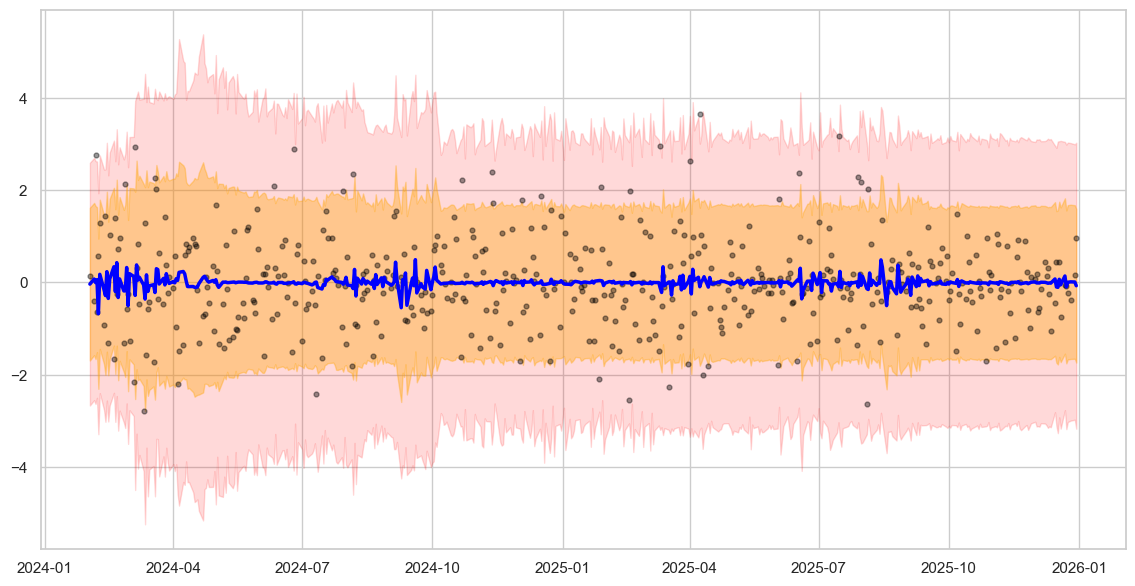

In [69]:

# dates_test_total = pd.Series([])

# pred_sigma_test_total = np.array([])
# pred_nu_test_total = np.array([])
# pred_mu_test_total = np.array([])


# 3. Create the distribution with the flattened parameters
test_dist = tfd.StudentT(
    df=pred_nu_test_total, 
    loc=pred_mu_test_total, 
    scale=pred_sigma_test_total
)

n_train = int(porcentage_train * len(df_X))
df_y_test = df_y.iloc[n_train:]
y_test = tf.convert_to_tensor(np.matrix(df_y_test))
y_test_flat = tf.reshape(y_test, [-1])

q_01 = test_dist.quantile(0.01).numpy()
q_05 = test_dist.quantile(0.05).numpy()
q_95 = test_dist.quantile(0.95).numpy()
q_99 = test_dist.quantile(0.99).numpy()

# 3. Set up the plot
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# --- PLOT THE RISK BANDS ---
# Plot the 1% to 99% Extreme Tail Risk interval (Light Red)
plt.fill_between(
    dates_test_total, q_01, q_99, 
    color='red', alpha=0.15, 
    label='1% - 99% Extreme Risk Band'
)

# Plot the 5% to 95% Standard Risk interval (Orange)
plt.fill_between(
    dates_test_total, q_05, q_95, 
    color='orange', alpha=0.35, 
    label='5% - 95% Standard Risk Band'
)

# --- PLOT THE DATA & MEAN ---
# Plot the raw, noisy market data
plt.scatter(
    dates_test_total, y_test_flat, 
    color='black', s=12, alpha=0.4, 
    label='Actual Market Returns'
)

# Plot the predicted center (Mu)
plt.plot(
    dates_test_total, pred_mu_test_total, 
    color='blue', lw=2.5, 
    label='Predicted Mean ($\mu_t$)'
)



In [61]:
stop

NameError: name 'stop' is not defined

In [ ]:
# df.index
# df_vix.index
# df['returns'] = np.log(df['prices']).diff()
# df_features = 100 * df[['returns']].copy()
# df_features = pd.concat([df_features, df_vix], axis=1)
# df_features.tail(200).head(50)
df_features.dropna(inplace=True)

In [ ]:
# from datetime import date
# from src.data.data_loader import fetch_asset_data
# from src.features.features import rolling_t_fit, features_lags, create_features

# start_date = date(2015, 12, 31)
# end_date = date(2025, 12, 31)
# window_size = 22 * 6
# porcentage_train = 0.8
# # model_classes = {'BTC-USD': 'Basic', 'ARKK': 'Residual', 'USO': 'Basic'} USDCLP=X
# ticker = 'USO'
# ticker = 'USDCLP=X'


# # ticker = 'BTC-USD'

# df = fetch_asset_data(ticker=ticker, start=start_date, end=end_date, features=[])
# if ticker == 'USDCLP=X':
#     df[df.prices < 200].prices = 680

# df_vix = fetch_asset_data(ticker='^VIX', start=start_date, end=end_date, features=[])
# df_vix = (df_vix[['prices']]) / np.sqrt(252)
# df_vix.columns = ['VIX']
# df_features = create_features(df, df_vix, window_size, n_lags=2)

df_features = df_features.astype('float32')
df_y = df_features['returns']
df_X = df_features.drop(columns=['returns'])

n_train = int(porcentage_train * len(df_X))
df_X_train = df_X.iloc[:n_train]
df_y_train = df_y.iloc[:n_train]

df_X_test = df_X.iloc[n_train:]
df_y_test = df_y.iloc[n_train:]
dates_test = df_X_test.index

X_train = tf.convert_to_tensor(np.matrix(df_X_train))
y_train = tf.convert_to_tensor(np.matrix(df_y_train))
X_test = tf.convert_to_tensor(np.matrix(df_X_test))
y_test = tf.convert_to_tensor(np.matrix(df_y_test))

In [ ]:
# ==========================================
# 3. TRAINING LOOP
# ==========================================
# model = WideAndDeepStudentTNet()
model = LinearStudentTNet()
optimizer = tf.keras.optimizers.Adam(learning_rate=0.015) 

@tf.function
def train_step(X_batch, y_batch):
    with tf.GradientTape() as tape:
        mu, sigma, nu = model(X_batch)
        loss = nll_loss_fn(mu, sigma, nu, y_batch)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss

epochs = 500
print("Training Wide & Deep Network on Polynomial Data...")


for epoch in range(epochs):
    loss = train_step(X_train, y_train)
    if epoch % 100 == 0:
        print(f"Epoch {epoch:03d} | NLL Loss: {loss.numpy():.4f}")

# @tf.function
# def train_step(X_batch, y_batch):
#     with tf.GradientTape() as tape:
#         mu, sigma, nu = model(X_batch)
#         loss = generalized_pit_moment_loss(mu, sigma, nu, y_batch)
#     gradients = tape.gradient(loss, model.trainable_variables)
#     optimizer.apply_gradients(zip(gradients, model.trainable_variables))
#     return loss

# epochs = 1500
# print("Training Linear Network...")
# for epoch in range(epochs):
#     loss_val = train_step(X_train, y_train)
#     if epoch % 100 == 0:
#         print(f"Epoch {epoch:03d} | Total Loss: {loss_val.numpy():.4f}")

Training Wide & Deep Network on Polynomial Data...
Epoch 000 | NLL Loss: 19.4386
Epoch 100 | NLL Loss: 1.6295
Epoch 200 | NLL Loss: 1.5390
Epoch 300 | NLL Loss: 1.5894
Epoch 400 | NLL Loss: 1.5154


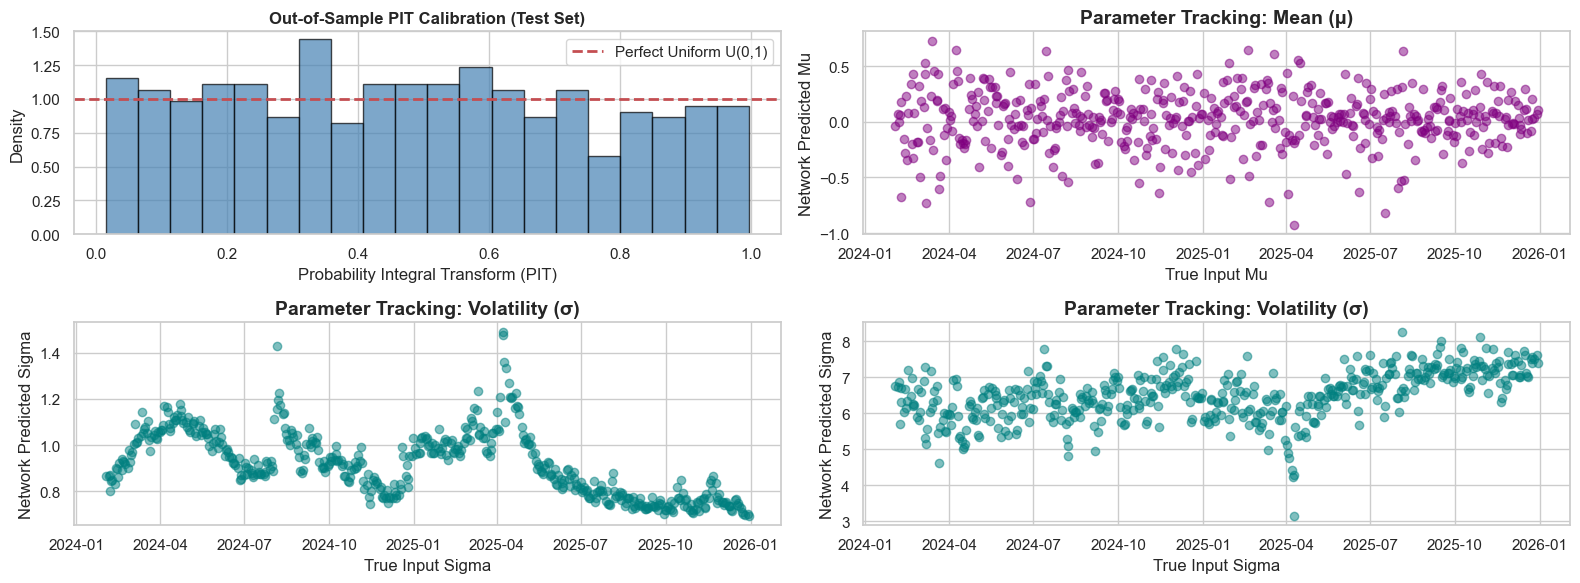


--- INDEPENDENT BLOCK TEST SUMMARY (495-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 0
True Failure Rate:        0.0%


,Start_Date,End_Date,KS_Stat,P_Value,Status
0,2024-02-02,2025-12-30,0.055716,0.089094,✅ PASSED


In [ ]:
pred_mu_test, pred_sigma_test, pred_nu_test = model(X_test)


# 1. Force predictions to be flat 1D tensors of shape (326,)
pred_mu_flat = tf.reshape(pred_mu_test, [-1])
pred_sigma_flat = tf.reshape(pred_sigma_test, [-1])
pred_nu_flat = tf.reshape(pred_nu_test, [-1])

df_pred_mu_flat = pd.DataFrame(pred_mu_flat, index=dates_test).tail(60)

# 2. Force the targets to be a flat 1D tensor of shape (326,)
y_test_flat = tf.reshape(y_test, [-1])

# 3. Create the distribution with the flattened parameters
test_dist = tfd.StudentT(
    df=pred_nu_flat, 
    loc=pred_mu_flat, 
    scale=pred_sigma_flat
)

# 4. Calculate CDF with the flattened targets
pit_values_test = test_dist.cdf(y_test_flat).numpy()

# Set up the Dashboard
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 6))

# --- PANEL 2: Out-of-Sample PIT Histogram ---
axes[0, 0].hist(pit_values_test, bins=20, density=True, color="steelblue", edgecolor='black', alpha=0.7)
axes[0, 0].axhline(y=1.0, color='r', linestyle='--', lw=2, label="Perfect Uniform U(0,1)")
axes[0, 0].set_title("Out-of-Sample PIT Calibration (Test Set)", fontweight='bold')
axes[0, 0].set_xlabel("Probability Integral Transform (PIT)")
axes[0, 0].set_ylabel("Density")
axes[0, 0].set_ylim(0, 1.5)
axes[0, 0].legend()

# --- Plot 2: Parameter Accuracy (Mu) ---
# A perfect model will align all points on the red dashed 45-degree line
axes[0, 1].scatter(dates_test, pred_mu_test, alpha=0.5, color="purple")
# axes[0, 1].plot([min(true_mu_test), max(true_mu_test)], [min(true_mu_test), max(true_mu_test)], 'r--', lw=2) 
axes[0, 1].set_title("Parameter Tracking: Mean (μ)", fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel("True Input Mu")
axes[0, 1].set_ylabel("Network Predicted Mu")

# --- Plot 3: Parameter Accuracy (Sigma) ---
axes[1, 0].scatter(dates_test, pred_sigma_test, alpha=0.5, color="teal")
# axes[1, 0].plot([min(true_sigma_test), max(true_sigma_test)], [min(true_sigma_test), max(true_sigma_test)], 'r--', lw=2)
axes[1, 0].set_title("Parameter Tracking: Volatility (σ)", fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel("True Input Sigma")
axes[1, 0].set_ylabel("Network Predicted Sigma")

# --- Plot 3: Parameter Accuracy (Sigma) ---
axes[1, 1].scatter(dates_test, pred_nu_test, alpha=0.5, color="teal")
# axes[1, 0].plot([min(true_sigma_test), max(true_sigma_test)], [min(true_sigma_test), max(true_sigma_test)], 'r--', lw=2)
axes[1, 1].set_title("Parameter Tracking: Volatility (σ)", fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel("True Input Sigma")
axes[1, 1].set_ylabel("Network Predicted Sigma")

plt.tight_layout()
plt.show()

df_pit_values_test = pd.DataFrame(pit_values_test, index=dates_test, columns=['PIT'])
block_ks_test(df_pit_values_test['PIT'], block_size=len(pit_values_test))

In [68]:
# df_y_test
len(q_05)

11

ValueError: 'x' has size 495, but 'y1' has an unequal size of 11

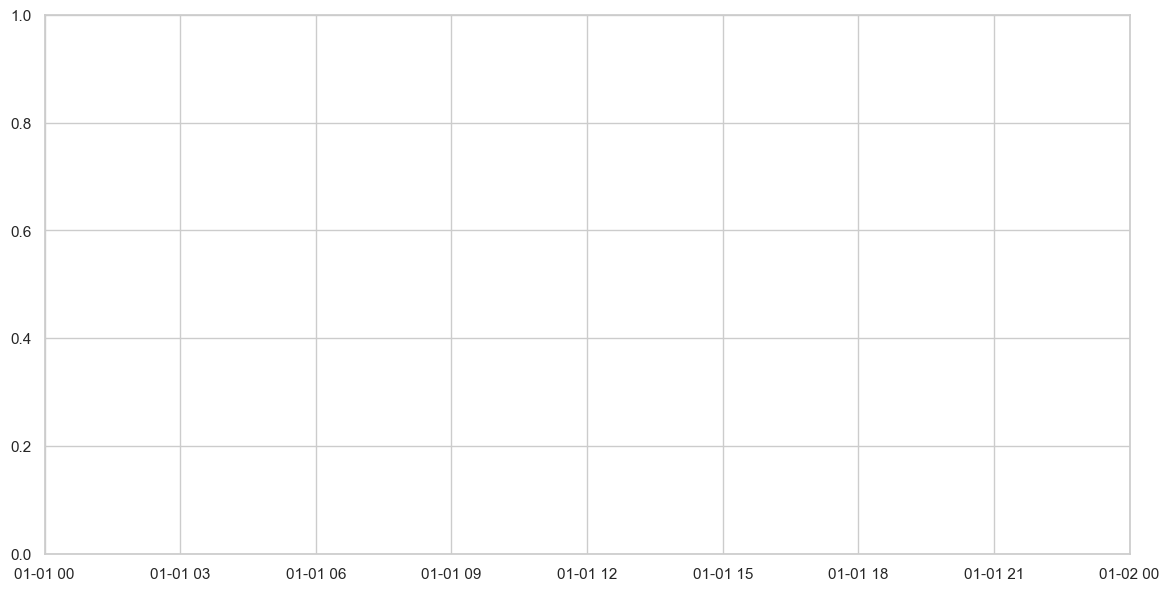

In [64]:
# 2. Calculate the exact mathematical percentiles from the predicted distribution
n_train = int(porcentage_train * len(df_X))
df_y_test = df_y.iloc[n_train:]
y_test = tf.convert_to_tensor(np.matrix(df_y_test))
y_test_flat = tf.reshape(y_test, [-1])

q_01 = test_dist.quantile(0.01).numpy()
q_05 = test_dist.quantile(0.05).numpy()
q_95 = test_dist.quantile(0.95).numpy()
q_99 = test_dist.quantile(0.99).numpy()

# 3. Set up the plot
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# --- PLOT THE RISK BANDS ---
# Plot the 1% to 99% Extreme Tail Risk interval (Light Red)
plt.fill_between(
    dates_test_total, q_01, q_99, 
    color='red', alpha=0.15, 
    label='1% - 99% Extreme Risk Band'
)

# Plot the 5% to 95% Standard Risk interval (Orange)
plt.fill_between(
    dates_test_total, q_05, q_95, 
    color='orange', alpha=0.35, 
    label='5% - 95% Standard Risk Band'
)

# --- PLOT THE DATA & MEAN ---
# Plot the raw, noisy market data
plt.scatter(
    dates_test_total, y_test_flat, 
    color='black', s=12, alpha=0.4, 
    label='Actual Market Returns'
)

# Plot the predicted center (Mu)
plt.plot(
    dates_test_total, pred_mu_test_total, 
    color='blue', lw=2.5, 
    label='Predicted Mean ($\mu_t$)'
)

In [ ]:
# ==========================================
# 5. RISK INTERVAL VISUALIZATION (EXCEEDANCE PLOT)
# ==========================================
import matplotlib.pyplot as plt
import numpy as np

# 1. Re-create the TFP distribution object using the model's flattened predictions
pred_dist = tfd.StudentT(df=pred_nu, loc=pred_mu, scale=pred_sigma)

# 2. Calculate the exact mathematical percentiles
q_01 = pred_dist.quantile(0.01).numpy()
q_05 = pred_dist.quantile(0.05).numpy()
q_95 = pred_dist.quantile(0.95).numpy()
q_99 = pred_dist.quantile(0.99).numpy()

# 3. Create Boolean Masks for Color Coding
t_flat = t_train.flatten()
y_flat = y_train_np.flatten()

# Extreme Outliers (Red): Below 1% OR Above 99%
mask_red = (y_flat < q_01) | (y_flat > q_99)

# Warning Tails (Yellow/Gold): Between 1%-5% OR Between 95%-99%
mask_yellow = ((y_flat >= q_01) & (y_flat <= q_05)) | ((y_flat >= q_95) & (y_flat <= q_99))

# Normal Returns (Black): Inside the 5% to 95% band
mask_normal = (y_flat > q_05) & (y_flat < q_95)

# 4. Set up the plot
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# --- PLOT THE RISK BANDS ---
plt.fill_between(t_flat, q_01, q_99, color='red', alpha=0.10, label='1% - 99% Risk Band')
plt.fill_between(t_flat, q_05, q_95, color='orange', alpha=0.20, label='5% - 95% Risk Band')

# --- PLOT THE MEAN ---
plt.plot(t_flat, pred_mu, color='blue', lw=2, label='Predicted Mean ($\mu_t$)')

# --- PLOT THE SCATTER POINTS BY TIER ---
# Normal
plt.scatter(t_flat[mask_normal], y_flat[mask_normal], 
            color='black', s=10, alpha=0.3, label='Normal Returns')

# Yellow (Warning)
# Adding a slight black edge makes yellow pop against the background
plt.scatter(t_flat[mask_yellow], y_flat[mask_yellow], 
            color='gold', s=25, alpha=0.9, edgecolor='black', linewidth=0.5, label='Tail Risk (1-5% / 95-99%)')

# Red (Extreme)
plt.scatter(t_flat[mask_red], y_flat[mask_red], 
            color='red', s=35, alpha=1.0, edgecolor='black', linewidth=0.8, label='Extreme Exceedance (<1% / >99%)')

# Formatting
plt.title('Exceedance Plot: Dynamic Quantiles vs Actual Market Reality', fontsize=16, fontweight='bold')
plt.xlabel('Time (t)', fontsize=12)
plt.ylabel('Returns', fontsize=12)
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.xlim(0, 1.0)
plt.tight_layout()
plt.show()

# ==========================================
# 6. EMPIRICAL CALIBRATION CHECK
# ==========================================
print("\n--- Empirical Coverage (Sanity Check) ---")
print(f"Expected points in Normal band (5-95%): ~90.00% | Actual: {(np.sum(mask_normal) / len(y_flat)) * 100:.2f}%")
print(f"Expected points in Yellow band:          ~8.00% | Actual: {(np.sum(mask_yellow) / len(y_flat)) * 100:.2f}%")
print(f"Expected points in Red band:             ~2.00% | Actual: {(np.sum(mask_red) / len(y_flat)) * 100:.2f}%")

In [ ]:
stop

NameError: name 'stop' is not defined

Training Linear Network...
Epoch 000 | Total Loss: -1.6629
Epoch 100 | Total Loss: -1.9594
Epoch 200 | Total Loss: -1.9594
Epoch 300 | Total Loss: -1.9595
Epoch 400 | Total Loss: -1.9595
Epoch 500 | Total Loss: -1.9596
Epoch 600 | Total Loss: -1.9596
Epoch 700 | Total Loss: -1.9596
Epoch 800 | Total Loss: -1.9597
Epoch 900 | Total Loss: -1.9598
Epoch 1000 | Total Loss: -1.9598
Epoch 1100 | Total Loss: -1.9598
Epoch 1200 | Total Loss: -1.9599
Epoch 1300 | Total Loss: -1.9599
Epoch 1400 | Total Loss: -1.9599
Epoch 1500 | Total Loss: -1.9599
Epoch 1600 | Total Loss: -1.9600
Epoch 1700 | Total Loss: -1.9578
Epoch 1800 | Total Loss: -1.9600
Epoch 1900 | Total Loss: -1.9600
Epoch 2000 | Total Loss: -1.9600
Epoch 2100 | Total Loss: -1.9600
Epoch 2200 | Total Loss: -1.9593
Epoch 2300 | Total Loss: -1.9599
Epoch 2400 | Total Loss: -1.9599
Epoch 2500 | Total Loss: -1.9598
Epoch 2600 | Total Loss: -1.9600
Epoch 2700 | Total Loss: -1.9598
Epoch 2800 | Total Loss: -1.9600
Epoch 2900 | Total Loss: -

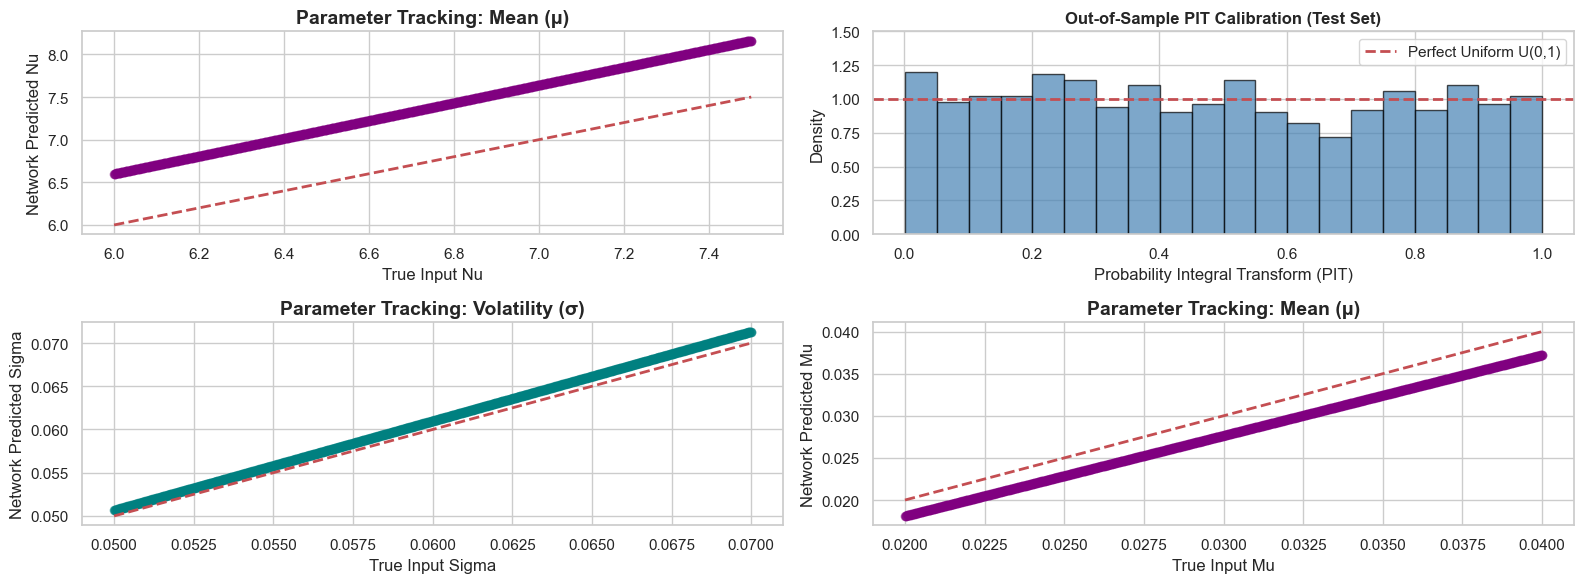


--- INDEPENDENT BLOCK TEST SUMMARY (1000-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 0
True Failure Rate:        0.0%

--- Out-of-Sample Diagnostic Stats ---
Test Set Average Predicted Sigma: 0.0610 (Target: 0.05)
Test Set Average Predicted Nu:    7.3797 (Target: 10)


In [ ]:
# ==========================================
# 1. GENERATE TRAIN & TEST DATA (Extrapolating Time)
# ==========================================
np.random.seed(42)
tf.random.set_seed(42)

N_TRAIN = 2000
N_TEST = 1000
# TRUE_SIGMA = 0.05
TRUE_NU = 10

# Time: Train is 0 to 1, Test is 1 to 1.25 (Predicting the future)
t_train = np.linspace(0, 1, N_TRAIN).astype(np.float32).reshape(-1, 1)
t_test = np.linspace(1, 1.5, N_TEST).astype(np.float32).reshape(-1, 1)

# True Mu equation: mu_t = 0.04 * t - 0.02
a = 0.04
b = 0.02
true_mu_train = a * t_train - b
true_mu_test = a * t_test - b

# Sigma (Volatility) expands from 1% to 5% over the train set
true_sigma_train = 0.01 + 0.04 * t_train
true_sigma_test = 0.01 + 0.04 * t_test

# Nu goes from 3 (Fat tails) to 23 (Thin tails) over the train set
true_nu_train = 3 * t_train + 3.0
true_nu_test = 3 * t_test + 3.0

# Generate targets point-by-point to allow dynamic df (nu)
noise_train = np.array([np.random.standard_t(df=v) for v in true_nu_train.flatten()]).astype(np.float32).reshape(-1, 1)
noise_test = np.array([np.random.standard_t(df=v) for v in true_nu_test.flatten()]).astype(np.float32).reshape(-1, 1)

# # Noise and Target Variables
# noise_train = np.random.standard_t(df=TRUE_NU, size=(N_TRAIN, 1)).astype(np.float32)
# noise_test = np.random.standard_t(df=TRUE_NU, size=(N_TEST, 1)).astype(np.float32)

y_train_np = true_mu_train + (true_sigma_train * noise_train)
y_test_np = true_mu_test + (true_sigma_test * noise_test)

X_train = tf.convert_to_tensor(t_train)
y_train = tf.convert_to_tensor(y_train_np)
X_test = tf.convert_to_tensor(t_test)
y_test = tf.convert_to_tensor(y_test_np)

## TRAINING LOOP

In [ ]:
# ==========================================
# 3. TRAINING LOOP
# ==========================================
model = LinearStudentTNet()
optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

@tf.function
def train_step(X_batch, y_batch):
    with tf.GradientTape() as tape:
        mu, sigma, nu = model(X_batch)
        loss = generalized_pit_moment_loss(mu, sigma, nu, y_batch)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss

epochs = 10000
print("Training Linear Network...")
for epoch in range(epochs):
    loss_val = train_step(X_train, y_train)
    if epoch % 100 == 0:
        print(f"Epoch {epoch:03d} | Total Loss: {loss_val.numpy():.4f}")



## OUT-OF-SAMPLE EVALUATION & PLOTTING

In [ ]:
# ==========================================
# 4. OUT-OF-SAMPLE EVALUATION & PLOTTING
# ==========================================
# Predict on Train AND Test sets

pred_mu_train, pred_sigma_train, pred_nu_train = model(X_train)
pred_mu_test, pred_sigma_test, pred_nu_test = model(X_test)

# Calculate Out-of-Sample PIT values
test_dist = tfd.StudentT(df=pred_nu_test, loc=pred_mu_test, scale=pred_sigma_test)
pit_values_test = test_dist.cdf(y_test).numpy().flatten()

# Set up the Dashboard
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 6))

# --- PANEL 1: Trend Tracking (Train & Test) ---
# # Train data
# axes[0, 0].scatter(t_train.flatten(), y_train_np.flatten(), alpha=0.2, color='gray', s=10, label="Train Returns")
# axes[0, 0].plot(t_train.flatten(), true_mu_train.flatten(), 'k--', lw=2, label="True Mu")
# axes[0, 0].plot(t_train.flatten(), pred_mu_train.numpy().flatten(), 'r-', lw=2, label="Predicted Mu (Train)")

# # Test data (The Future)
# axes[0, 0].scatter(t_test.flatten(), y_test_np.flatten(), alpha=0.4, color='orange', s=10, label="Test Returns")
# axes[0, 0].plot(t_test.flatten(), true_mu_test.flatten(), 'k--', lw=2)
# axes[0, 0].plot(t_test.flatten(), pred_mu_test.numpy().flatten(), 'b-', lw=3, label="Predicted Mu (Test)")

# axes[0, 0].axvline(x=1.0, color='red', linestyle=':', lw=2, label="Out-of-Sample Split")
# axes[0, 0].set_title("Tracking the Trend: In-Sample vs Out-of-Sample", fontweight='bold')
# axes[0, 0].set_xlabel("Time (t)")
# axes[0, 0].set_ylabel("Return")
# axes[0, 0].legend()
# --- Plot 2: Parameter Accuracy (Mu) ---
# A perfect model will align all points on the red dashed 45-degree line
axes[0, 0].scatter(true_nu_test, pred_nu_test, alpha=0.5, color="purple")
axes[0, 0].plot([min(true_nu_test), max(true_nu_test)], [min(true_nu_test), max(true_nu_test)], 'r--', lw=2) 
axes[0, 0].set_title("Parameter Tracking: Mean (μ)", fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel("True Input Nu")
axes[0, 0].set_ylabel("Network Predicted Nu")

# --- PANEL 2: Out-of-Sample PIT Histogram ---
axes[0, 1].hist(pit_values_test, bins=20, density=True, color="steelblue", edgecolor='black', alpha=0.7)
axes[0, 1].axhline(y=1.0, color='r', linestyle='--', lw=2, label="Perfect Uniform U(0,1)")
axes[0, 1].set_title("Out-of-Sample PIT Calibration (Test Set)", fontweight='bold')
axes[0, 1].set_xlabel("Probability Integral Transform (PIT)")
axes[0, 1].set_ylabel("Density")
axes[0, 1].set_ylim(0, 1.5)
axes[0, 1].legend()

# --- Plot 2: Parameter Accuracy (Mu) ---
# A perfect model will align all points on the red dashed 45-degree line
axes[1, 1].scatter(true_mu_test, pred_mu_test, alpha=0.5, color="purple")
axes[1, 1].plot([min(true_mu_test), max(true_mu_test)], [min(true_mu_test), max(true_mu_test)], 'r--', lw=2) 
axes[1, 1].set_title("Parameter Tracking: Mean (μ)", fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel("True Input Mu")
axes[1, 1].set_ylabel("Network Predicted Mu")

# --- Plot 3: Parameter Accuracy (Sigma) ---
axes[1, 0].scatter(true_sigma_test, pred_sigma_test, alpha=0.5, color="teal")
axes[1, 0].plot([min(true_sigma_test), max(true_sigma_test)], [min(true_sigma_test), max(true_sigma_test)], 'r--', lw=2)
axes[1, 0].set_title("Parameter Tracking: Volatility (σ)", fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel("True Input Sigma")
axes[1, 0].set_ylabel("Network Predicted Sigma")

plt.tight_layout()
plt.show()

block_ks_test(pd.DataFrame(pit_values_test), block_size=len(pit_values_test))

# Print Final Diagnostic Stats
print("\n--- Out-of-Sample Diagnostic Stats ---")
print(f"Test Set Average Predicted Sigma: {tf.reduce_mean(pred_sigma_test).numpy():.4f} (Target: {TRUE_SIGMA})")
print(f"Test Set Average Predicted Nu:    {tf.reduce_mean(pred_nu_test).numpy():.4f} (Target: {TRUE_NU})")